# CNN Model Comparison — Validation Set

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pandas as pd
from PIL import Image
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Data — validation split

In [10]:
ustc = load_dataset("jonathan-roberts1/USTC_SmokeRS", split="train")
class_names = ustc.features["label"].names
print(f"Dataset loaded: {len(ustc)} images, classes: {class_names}")

Dataset loaded: 6225 images, classes: ['cloud', 'dust', 'haze', 'land', 'seaside', 'smoke']


In [11]:
TARGET_SIZE = (224, 224)

def load_ustc(pil_image):
    return np.array(pil_image.resize(TARGET_SIZE, Image.BILINEAR))

def normalise(img):
    return img.astype(np.float32) / 255.0

def load_split(df, normalise_fn):
    X = np.stack([normalise_fn(load_ustc(ustc[i]["image"])) for i in df["index"]])
    y = df["label"].values
    return X, y

pool = pd.DataFrame([{"index": i, "label": row["label"]} for i, row in enumerate(ustc)])
train_val, test = train_test_split(pool, test_size=0.20, stratify=pool["label"], random_state=42)
train, val      = train_test_split(train_val, test_size=0.25, stratify=train_val["label"], random_state=42)

X_val_norm, y_val = load_split(val, normalise)
print(f"Validation set: {X_val_norm.shape}  labels: {y_val.shape}")

Validation set: (1245, 224, 224, 3)  labels: (1245,)


## Load models

In [12]:
model_files = {
    "Baseline CNN":        "cnn_model.h5",
    "V1 — 4th Block":      "tuning_models/cnn_v1_best.h5",
    "V2 — Two-Layer Head": "tuning_models/cnn_v2_best.h5",
    "V3 — Wide Dense":     "tuning_models/cnn_v3_best.h5",
    "V4 — Half-Width":     "tuning_models/cnn_v4_best.h5",
    "V5 — Double-Width":   "tuning_models/cnn_v5_best.h5",
}

models = {name: tf.keras.models.load_model(path, compile=False) for name, path in model_files.items()}
print("All models loaded:")
for name, m in models.items():
    print(f"  {name:<25} params: {m.count_params():,}")

All models loaded:
  Baseline CNN              params: 324,390
  V1 — 4th Block            params: 1,244,454
  V2 — Two-Layer Head       params: 490,790
  V3 — Wide Dense           params: 431,142
  V4 — Half-Width           params: 92,182
  V5 — Double-Width         params: 1,217,350


## Evaluation

### Baseline CNN

In [13]:
y_pred_baseline_cnn = np.argmax(models["Baseline CNN"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_baseline_cnn, target_names=class_names))

2026-04-28 13:22:53.854127: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step
              precision    recall  f1-score   support

       cloud       0.72      0.91      0.81       233
        dust       0.77      0.66      0.71       202
        haze       0.77      0.54      0.63       200
        land       0.78      0.74      0.76       206
     seaside       0.61      0.99      0.76       201
       smoke       0.56      0.33      0.41       203

    accuracy                           0.70      1245
   macro avg       0.70      0.69      0.68      1245
weighted avg       0.70      0.70      0.68      1245



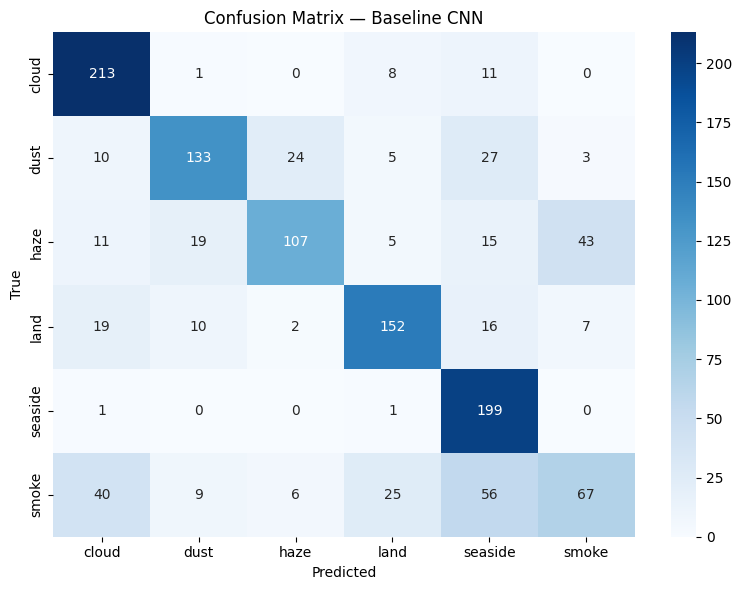

In [14]:
cm_baseline_cnn = confusion_matrix(y_val, y_pred_baseline_cnn)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_baseline_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Baseline CNN')
plt.tight_layout()
plt.show()

### V1 — 4th Block

In [15]:
y_pred_v1 = np.argmax(models["V1 — 4th Block"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_v1, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 481ms/step
              precision    recall  f1-score   support

       cloud       0.78      0.72      0.75       233
        dust       0.76      0.55      0.64       202
        haze       0.69      0.53      0.60       200
        land       0.78      0.69      0.73       206
     seaside       0.53      1.00      0.69       201
       smoke       0.53      0.45      0.49       203

    accuracy                           0.66      1245
   macro avg       0.68      0.65      0.65      1245
weighted avg       0.68      0.66      0.65      1245



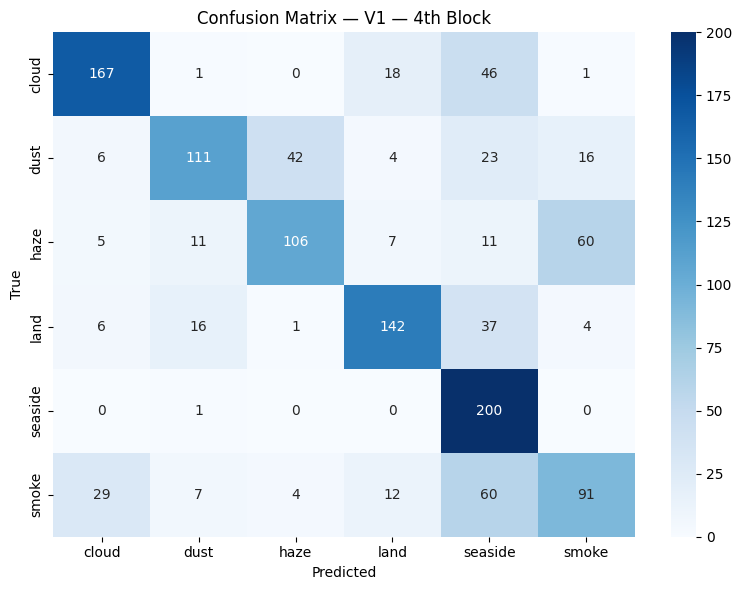

In [16]:
cm_v1 = confusion_matrix(y_val, y_pred_v1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — V1 — 4th Block')
plt.tight_layout()
plt.show()

### V2 — Two-Layer Head

In [17]:
y_pred_v2 = np.argmax(models["V2 — Two-Layer Head"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_v2, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step
              precision    recall  f1-score   support

       cloud       0.72      0.90      0.80       233
        dust       0.76      0.66      0.70       202
        haze       0.83      0.49      0.62       200
        land       0.67      0.78      0.72       206
     seaside       0.71      0.97      0.82       201
       smoke       0.57      0.40      0.47       203

    accuracy                           0.71      1245
   macro avg       0.71      0.70      0.69      1245
weighted avg       0.71      0.71      0.69      1245



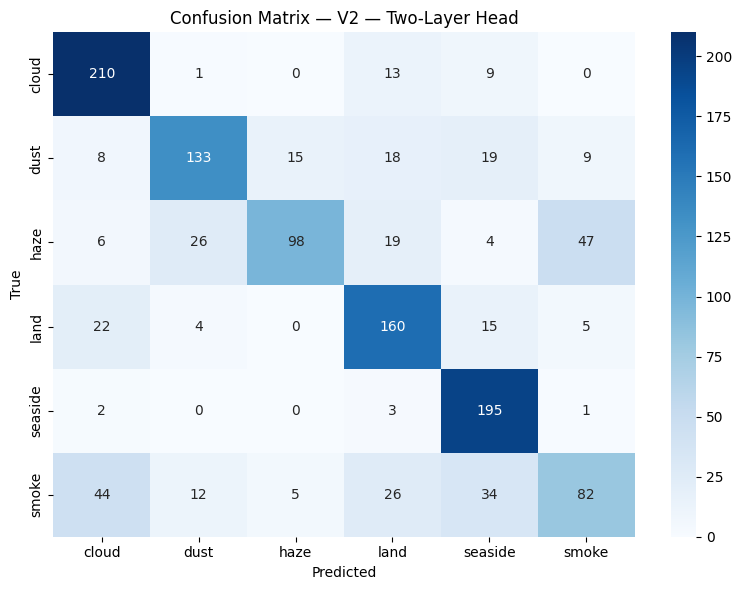

In [18]:
cm_v2 = confusion_matrix(y_val, y_pred_v2)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — V2 — Two-Layer Head')
plt.tight_layout()
plt.show()

### V3 — Wide Dense

In [19]:
y_pred_v3 = np.argmax(models["V3 — Wide Dense"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_v3, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step
              precision    recall  f1-score   support

       cloud       0.75      0.82      0.78       233
        dust       0.64      0.76      0.70       202
        haze       0.83      0.47      0.60       200
        land       0.76      0.68      0.72       206
     seaside       0.63      0.99      0.77       201
       smoke       0.54      0.35      0.43       203

    accuracy                           0.68      1245
   macro avg       0.69      0.68      0.67      1245
weighted avg       0.69      0.68      0.67      1245



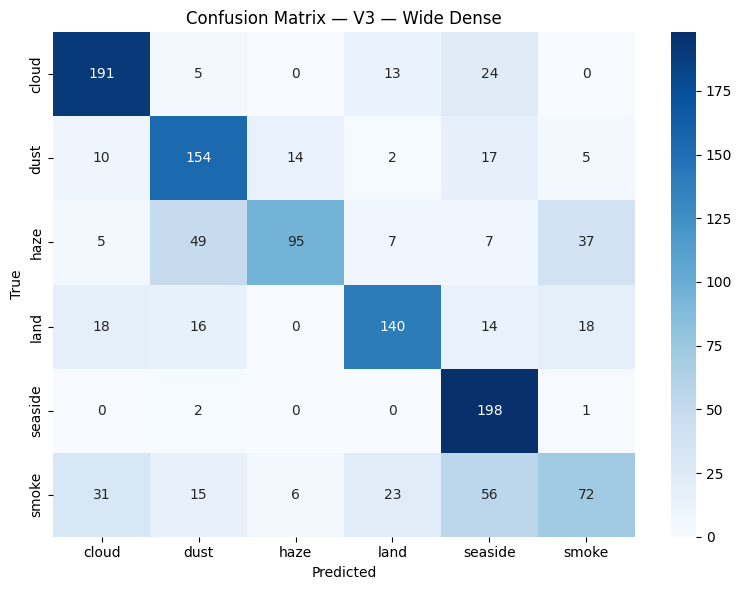

In [20]:
cm_v3 = confusion_matrix(y_val, y_pred_v3)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — V3 — Wide Dense')
plt.tight_layout()
plt.show()

### V4 — Half-Width

In [21]:
y_pred_v4 = np.argmax(models["V4 — Half-Width"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_v4, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step
              precision    recall  f1-score   support

       cloud       0.79      0.79      0.79       233
        dust       0.62      0.77      0.68       202
        haze       0.82      0.35      0.49       200
        land       0.78      0.66      0.71       206
     seaside       0.49      0.99      0.66       201
       smoke       0.48      0.23      0.31       203

    accuracy                           0.63      1245
   macro avg       0.66      0.63      0.61      1245
weighted avg       0.66      0.63      0.61      1245



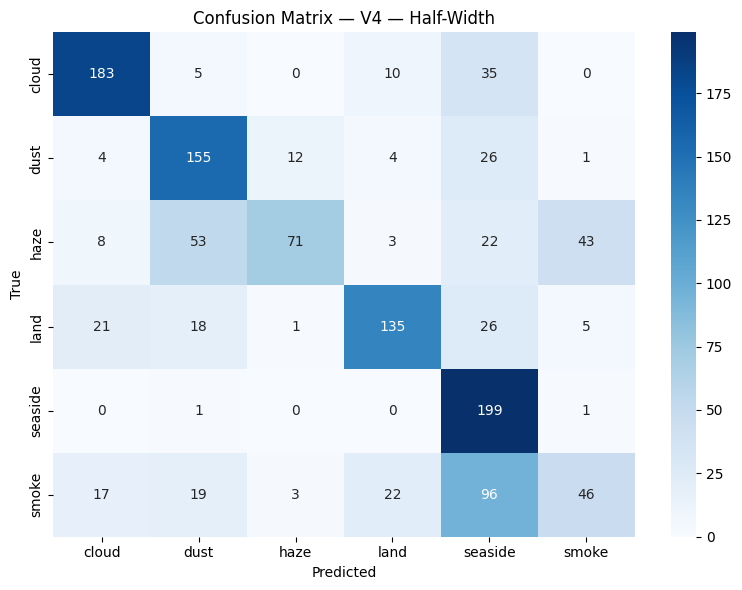

In [22]:
cm_v4 = confusion_matrix(y_val, y_pred_v4)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_v4, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — V4 — Half-Width')
plt.tight_layout()
plt.show()

### V5 — Double-Width

In [23]:
y_pred_v5 = np.argmax(models["V5 — Double-Width"].predict(X_val_norm), axis=1)
print(classification_report(y_val, y_pred_v5, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step
              precision    recall  f1-score   support

       cloud       0.82      0.85      0.83       233
        dust       0.72      0.71      0.72       202
        haze       0.80      0.57      0.67       200
        land       0.79      0.66      0.72       206
     seaside       0.52      0.99      0.69       201
       smoke       0.50      0.27      0.35       203

    accuracy                           0.68      1245
   macro avg       0.69      0.67      0.66      1245
weighted avg       0.70      0.68      0.67      1245



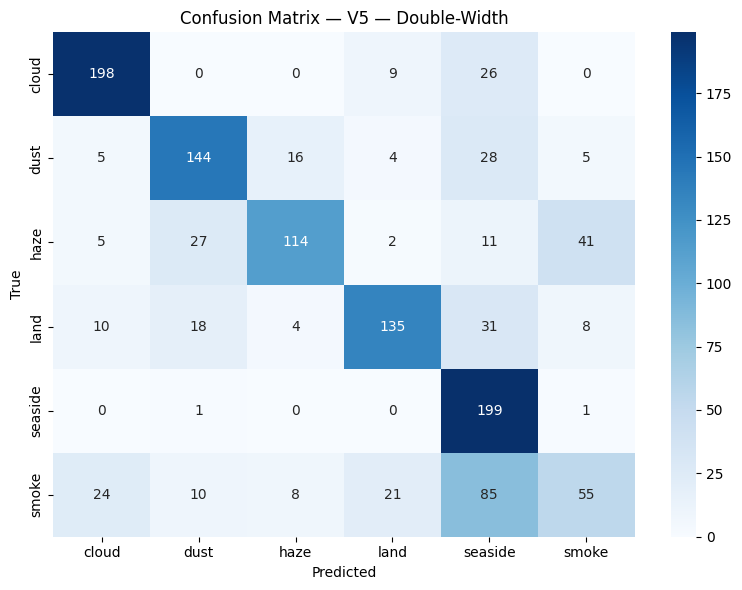

In [24]:
cm_v5 = confusion_matrix(y_val, y_pred_v5)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_v5, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — V5 — Double-Width')
plt.tight_layout()
plt.show()